## EXPLORATORY DATA ANALYSIS - YOUTH TOBACCO EXPOSURE IN INDIA

### Dataset : 
Global Youth Tobacco Survey (India), 2019
https://data.gov.in/resource/global-youth-tobacco-survey-gyts-4-india-and-states-2019
### Author : 
Abhinayaa Kumar Subramanian

### Objective:
This notebook explores the state-level patterns in youth exposure to tobacco and examines how education, geographical location, awareness and policy enforcement affect exposure outcomes. The target group is school-going youth below the age of 18.

### Research Questions:
1. Are urban students more exposed to second-hand smoke than rural students?
2. Is anti-tobacco education associated with support for smoking bans?
3. Does policy enforcement (COTPA - Cigarettes & Other Tobacco Products Act) correlate with reduced exposure?
4. Is geographical location associated with different levels of smoke exposure?

### Key Findings 
- Urban exposure (37.97%) exceeds rural exposure (35.44%) by 2.53pp on average, with higher median and upper-tail dispersion in urban areas.
- Anti-tobacco education is moderately correlated with ban support (ρ = 0.32).
- COTPA enforcement shows weak positive association with exposure (ρ = 0.23), suggesting enforcement is reactive rather than preventive.
- North-eastern states show 22.4pp higher smoke exposure and northern states show 7.9pp lower exposure when compared to the other states of India. This gap could potentially be driven by climatic or other cultural factors.

### Note on Variable Selection: 
This analysis uses "tobacco smoke exposure" (secondhand smoke at home/public places) as the primary outcome variable rather than direct consumption. This choice reflects two considerations: \
(1) direct consumption among school-going youth below 18 is likely underreported due to social desirability bias, and \
(2) exposure captures the broader environmental tobacco risk faced by this population, making it the more policy-relevant outcome for school-based intervention design.

<img src="download.webp" width="700" style="display:block; margin-left:0">

### IMPORTING LIBRARIES & DATA LOADING

In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [238]:
tsmoke = pd.read_csv('Total.csv') 
usmoke = pd.read_csv('urban.csv')
rsmoke = pd.read_csv('Rural.csv')

### DATA CLEANING & VARIABLE CONSTRUCTION

In [239]:
tsmoke.head(2)  

,State/UT,Area,Current tobacco users (%),Current tobacco smokers (%),Current cigarette users (%),Current bidi users (%),Median age of initiation of Cigarette (in years),Median age of initiation of Bidi (in years),Awareness about e-cigarette (%),Exposure to tobacco smoke at home/public place (%),...,Refused sale of bidi because of age in past 30 days (%),Students who noticed anti-tobacco messages anywhere in past 30 days (%),Students who noticed health warnings on any tobacco product/cigarette packages in past 30 days (%),Students who saw tobacco advertisements anywhere in past 30 days (%),Students who were taught in class about harmful effects of tobacco use during past 12 months (%),Students who thought it is difficult to quit once someone starts smoking tobacco (%),Students who thought other people’s tobacco smoking is harmful to them (%),Students who favoured ban on smoking at outdoor public places (%),"School heads aware of COTPA, 2003 (%)","Schools authorized by the state government to collect fine for violation under Section-6 of the COTPA, 2003 (%)"
0,India,Total,8.5,7.3,2.6,2.1,11.5,10.5,26.9,29.5,...,52.7,71.3,25.2,60.6,37.8,26.0,70.6,60.5,85.4,38.2
1,Andaman and Nicobar Islands,Total,4.4,3.7,1.3,1.0,12.0,12.3,13.6,35.6,...,63.2,74.0,29.2,57.4,23.4,23.0,69.0,60.6,88.6,1.1


In [240]:
RENAME_COLS = {
    "State/UT": "state",
    "Area": "area",
    "Median age of initiation of Cigarette (in years)": "age_init_cig",
    "Median age of initiation of Bidi (in years)": "age_init_bidi",
    "Awareness about e-cigarette (%)": "aware_ecig_pct",
    "Exposure to tobacco smoke at home/public place (%)": "smoke_exposure_pct",
    "Students who saw anyone smoking inside the  school building or outside school property (%)": "smoking_near_school_pct",
    "Refused sale of cigarette because of age in past 30 days   (%)": "refusal_cig_pct",
    "Refused sale of bidi because of age in past 30 days   (%)": "refusal_bidi_pct",
    "Students who noticed anti-tobacco messages anywhere in past 30 days    (%)": "anti_tobacco_msg_pct",
    "Students who noticed health warnings on any tobacco product/cigarette packages in past 30 days       (%)": "health_warning_pct",
    "Students who saw tobacco advertisements anywhere in past 30 days  (%)": "tobacco_ads_pct",
    "Students who were taught in class about harmful effects of tobacco use during past 12 months (%)": "taught_harm_pct",
    "Students who thought it is difficult to quit once someone starts smoking tobacco (%)": "quit_difficult_pct",
    "Students who thought other people’s tobacco smoking is harmful to them (%)": "smoking_harmful_pct",
    "Students who favoured ban on smoking at outdoor public places (%)": "support_ban_pct",
    "School heads aware of COTPA, 2003  (%)": "cotpa_awareness_pct",
    "Schools authorized by the state government to collect fine for violation under Section-6 of the COTPA, 2003  (%)": "cotpa_enforcement_pct"
}

for df in [tsmoke, usmoke, rsmoke]:
    df.rename(columns=RENAME_COLS, inplace=True)

In [241]:
common_cols = set(tsmoke.columns) & set(usmoke.columns) & set(rsmoke.columns)

order_common_cols = [col for col in tsmoke.columns if col in common_cols]

tsmoke = tsmoke[list(order_common_cols)]
usmoke = usmoke[list(order_common_cols)]
rsmoke = rsmoke[list(order_common_cols)]


In [242]:
tsmoke.head(2)

,state,area,age_init_cig,age_init_bidi,aware_ecig_pct,smoke_exposure_pct,smoking_near_school_pct,refusal_cig_pct,refusal_bidi_pct,anti_tobacco_msg_pct,health_warning_pct,tobacco_ads_pct,taught_harm_pct,quit_difficult_pct,smoking_harmful_pct,support_ban_pct,cotpa_awareness_pct,cotpa_enforcement_pct
0,India,Total,11.5,10.5,26.9,29.5,28.8,54.7,52.7,71.3,25.2,60.6,37.8,26.0,70.6,60.5,85.4,38.2
1,Andaman and Nicobar Islands,Total,12.0,12.3,13.6,35.6,29.0,59.8,63.2,74.0,29.2,57.4,23.4,23.0,69.0,60.6,88.6,1.1


### HANDLING MISSING/DUPLICATE VALUES

In [243]:
def check_data_quality(df, name):
    print(f"{name} — Missing values:\n", df.isnull().sum().sum())
    print(f"{name} — Duplicates:", df.duplicated().sum())

check_data_quality(tsmoke, "Total")
check_data_quality(usmoke, "Urban")
check_data_quality(rsmoke, "Rural")


Total — Missing values:
 0
Total — Duplicates: 0
Urban — Missing values:
 0
Urban — Duplicates: 0
Rural — Missing values:
 0
Rural — Duplicates: 0


### CONCATENATION 

In [244]:
tobacco = (pd.concat([usmoke.assign(area_type="Urban"), rsmoke.assign(area_type="Rural")], ignore_index=True))

# Tobacco is the concatenated dataset consisting of the datasets of rural areas and urban areas of states.

In [245]:
tobacco.to_csv("tobacco.csv", index = False)
tobacco = pd.read_csv("tobacco.csv")

### SUMMARY STATISTICS

In [246]:
summary_stats = tobacco.describe().round(2)
summary_stats.T

,count,mean,std,min,25%,50%,75%,max
age_init_cig,72.0,11.27,2.33,7.0,9.90,11.55,12.42,24.2
age_init_bidi,72.0,10.79,1.97,6.8,9.20,10.95,12.40,14.4
aware_ecig_pct,72.0,25.52,11.01,0.4,17.25,25.15,31.80,57.5
smoke_exposure_pct,72.0,36.71,16.80,0.9,25.40,32.30,46.05,74.4
smoking_near_school_pct,72.0,28.17,13.16,0.4,19.60,25.45,33.12,80.2
refusal_cig_pct,72.0,48.68,27.31,0.0,26.08,52.30,71.38,100.0
refusal_bidi_pct,72.0,51.74,31.08,0.0,25.18,57.35,78.32,100.0
anti_tobacco_msg_pct,72.0,74.80,9.78,41.4,67.35,75.30,81.08,99.0
health_warning_pct,72.0,30.11,13.43,0.4,22.67,26.90,32.05,72.3
tobacco_ads_pct,72.0,62.54,14.08,25.6,53.85,63.65,69.32,99.5


-------------------------------------------------

### RESEARCH METHODS

### RQ1: Urban Vs Rural Exposure
### Do urban students experience higher tobacco smoke exposure than rural students?

In [247]:
area_summary = tobacco.groupby("area_type")[["smoke_exposure_pct"]].agg(["mean","median","min","max"]).round(2)
area_summary.T                                                                                          

area_type                  Rural  Urban
smoke_exposure_pct mean    35.44  37.97
                   median  31.10  34.05
                   min      9.20   0.90
                   max     73.70  74.40

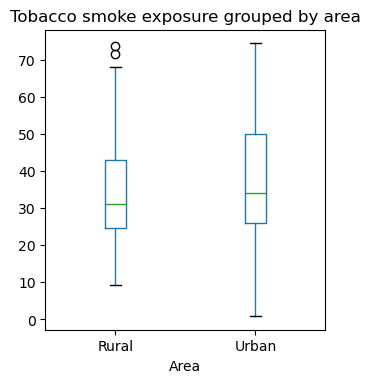

In [248]:
tobacco.boxplot( column="smoke_exposure_pct", by="area",grid=False, figsize=(3.5,4))
plt.title("Tobacco smoke exposure grouped by area")
plt.suptitle("")
plt.xlabel("Area")
plt.show()

### Interpretation 
From the boxplot, urban areas show higher median tobacco exposure and greater upper tail dispersion compared to rural areas, suggesting higher average exposure along with more extreme outliers. 

However, while urban areas show higher exposure than rural areas descriptively, this finding loses significance in the multivariate regression done later in the project. This indicates that the urban-rural gap is due to other compositional factors included but not limited to education and enforcement across areas rather than urbanisation itself. 

-------------------------------------------------

### RQ2: Education Vs Support for Ban
### Is anti-tobacco education associated with support for smoking bans?

In [249]:
correlation = tobacco["taught_harm_pct"].corr(tobacco["support_ban_pct"]).round(2)
print(f"Correlation between Anti-tobacco education & Support for ban is {correlation}.")

Correlation between Anti-tobacco education & Support for ban is 0.32.


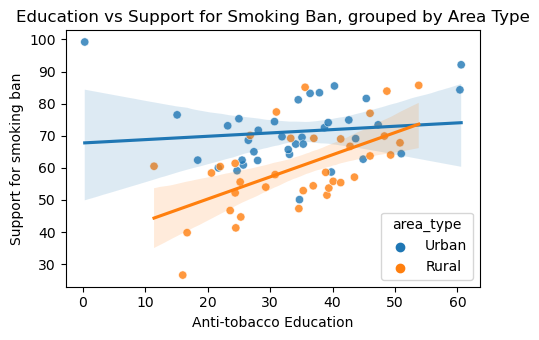

In [250]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3.5))
sns.scatterplot(data=tobacco, x="taught_harm_pct", y="support_ban_pct", hue="area_type", alpha=0.8)
sns.regplot(data=tobacco[tobacco["area_type"]=="Urban"], x="taught_harm_pct", y="support_ban_pct", scatter=False)
sns.regplot(data=tobacco[tobacco["area_type"]=="Rural"], x="taught_harm_pct", y="support_ban_pct", scatter=False)
plt.title("Education vs Support for Smoking Ban, grouped by Area Type")
plt.xlabel("Anti-tobacco Education")
plt.ylabel("Support for smoking ban")
plt.tight_layout()
plt.show()

In [251]:
tobacco["taught_harm_pct"].corr(tobacco["support_ban_pct"]).round(2)

0.32

### Interpretation
The relationship between anti-tobacco school education and support for banning tobacco is positive (correlation = 0.32) in both rural and urban areas. However, the slope coefficient of the regression is higher for rural areas than urban areas, suggesting that education may more strongly translate into pro-ban support for tobacco in rural areas. 

However, the fitted regression line only suggests correlation and no causaul inference due to "omitted variable bias and reverse causality". 

-------------------------------------------------

### RQ 3 Exposure Vs Enforcement
### Does policy enforcement (COTPA) correlate with reduced exposure?

In [278]:
tobacco["Enforcement Bin"] = pd.qcut(tobacco["cotpa_enforcement_pct"], q=3, labels=["Low", "Medium", "High"])

pd.pivot_table(tobacco,values="smoke_exposure_pct",index="Enforcement Bin",aggfunc=["mean", "median"]).round(2)

,mean,median
,smoke_exposure_pct,smoke_exposure_pct
Enforcement Bin,,
Low,34.99,35.7
Medium,34.49,30.6
High,42.71,34.8


<function matplotlib.pyplot.show(close=None, block=None)>

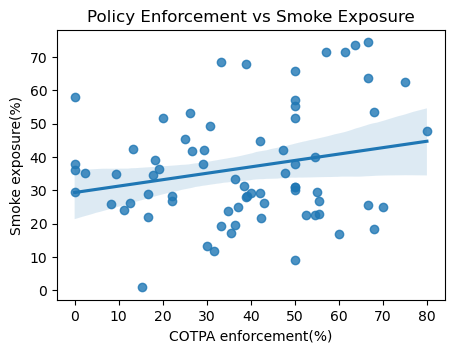

In [253]:
plt.figure(figsize=(5,3.5))
sns.regplot(data=tobacco, x="cotpa_enforcement_pct", y="smoke_exposure_pct")
plt.title("Policy Enforcement vs Smoke Exposure")
plt.xlabel("COTPA enforcement(%)")
plt.ylabel("Smoke exposure(%)")
plt.show

### Interpretation
It is evident that smoke exposure is "higher" in high enforcement areas(42.71%) than in low enforcement areas (34.99%). This is counterintuitive as in enforcement policies are more reactive than preventive, as seen from the positive slope of the regression plot between the variables. 

This is further reinforced from the regression analysis done later where the COTPA enforcement variable is statistically insignificant (p= 0.127) once other factors are controlled for. 

-------------------------------------------------

### RQ4: Geographical location as a factor
### Are geographic locations associated with different levels of smoke exposure?

In [254]:
northeast = ["Arunachal Pradesh", "Nagaland", "Meghalaya", "Mizoram", "Manipur", "Assam", "Tripura", "Sikkim"]

north = ["Himachal Pradesh", "Uttarakhand", "Jammu and Kashmir", "Punjab", "Haryana", "Rajasthan", "Delhi", "Chandigarh"]

tobacco["region"] = "Rest of India"
tobacco.loc[tobacco["state"].isin(northeast), "region"] = "Northeast"
tobacco.loc[tobacco["state"].isin(north), "region"] = "North"

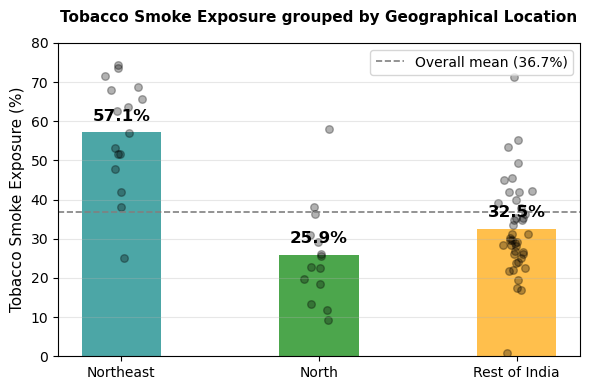

In [281]:
northeast_mean = tobacco[tobacco["region"] == "Northeast"]["smoke_exposure_pct"].mean()
north_mean = tobacco[tobacco["region"] == "North"]["smoke_exposure_pct"].mean()
rest_mean = tobacco[tobacco["region"] == "Rest of India"]["smoke_exposure_pct"].mean()

fig, ax = plt.subplots(figsize=(6, 4))

categories = ['Northeast', 'North', 'Rest of India']
means = [northeast_mean, north_mean, rest_mean]
colors = ['teal', 'green', 'orange']

bars = ax.bar(categories, means, color=colors, width=0.4, alpha=0.7)

for i, region in enumerate(['Northeast', 'North', 'Rest of India']):
    region_data = tobacco[tobacco["region"] == region]["smoke_exposure_pct"]
    ax.scatter(np.random.normal(i, 0.04, len(region_data)),region_data, color='black', alpha=0.3, s=30)

ax.text(0, northeast_mean + 3, f'{northeast_mean:.1f}%', ha='center', fontsize=12, fontweight='bold', color='black')
ax.text(1, north_mean + 3, f'{north_mean:.1f}%', ha='center', fontsize=12, fontweight='bold', color='black')
ax.text(2, rest_mean + 3, f'{rest_mean:.1f}%', ha='center', fontsize=12, fontweight='bold', color='black')

ax.axhline(y=tobacco["smoke_exposure_pct"].mean(), color='grey',
           linestyle='--', linewidth=1.2,
           label=f'Overall mean ({tobacco["smoke_exposure_pct"].mean():.1f}%)')

ax.set_title("Tobacco Smoke Exposure grouped by Geographical Location",fontsize=11, fontweight='bold', pad=15)
ax.set_ylabel("Tobacco Smoke Exposure (%)", fontsize=11)
ax.set_ylim(0, 80)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation
On average, north-eastern states show higher smoke exposure(57.1%), than northern states(34.4%) and rest of India (32.5%) - more than 20.4pp above the national mean of 36.7%. 

Statistically, for the north-eastern states, the distribution is skewed upwards with several states clustering between 50-75% range and there is higher within-group variation. However, in northern states, there seems to be greater within-group consistency with state-level observations clustering between 10-30%. The other states behave very close to the national mean of 32.5% but is the most dispersed among the 3 groups. 

However, there is considerable overlap in individual state exposures across the categories. Therefore, group-level averages should not be interpreted deterministically - regression analysis provodes a more robust test to see if region is a statistically significant predictor of smoke exposure. 

-------------------------------------------------

### CORRELATION ANALYSIS 

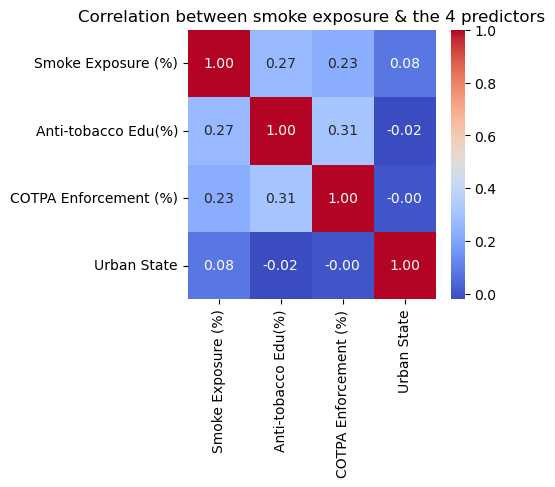

In [266]:
tobacco['is_urban'] = (tobacco['area_type'] == 'Urban').astype(int)
corr_vars = ["smoke_exposure_pct", "taught_harm_pct", "cotpa_enforcement_pct", "is_urban"]

label_map = {"smoke_exposure_pct": "Smoke Exposure (%)",
    "taught_harm_pct": "Anti-tobacco Edu(%)",
    "cotpa_enforcement_pct": "COTPA Enforcement (%)",
    "is_urban": "Urban State"}

corr_matrix = tobacco[corr_vars].corr().round(2)
corr_matrix.rename(index=label_map, columns=label_map, inplace=True)
plt.figure(figsize=(4,3.5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between smoke exposure & the 4 predictors")
plt.show()

-------------------------------------------------

### DESCRIPTION TO MODELLING

The groupby and correlation commands identify 4 important predictors - Education, Enforcement, Cold/Non-cold States and Urban/Rural areas of states. The following regression analysis aims to study the isolated associations of these predictors with tobacco smoke exposure, controlling for any confounding between them.

-------------------------------------------------

### REGRESSION ANALYSIS

In [273]:
corr_check = tobacco[['health_warning_pct', 'taught_harm_pct', 'smoke_exposure_pct']].corr().round(2)
print(corr_check)

                    health_warning_pct  taught_harm_pct  smoke_exposure_pct
health_warning_pct                1.00             0.41                0.78
taught_harm_pct                   0.41             1.00                0.27
smoke_exposure_pct                0.78             0.27                1.00


### Variable selection for the regression
The selected variables of the regression give an R² of 0.48 exlaining about 48% of the total variation in the data. The variable "% of health warnings on tobacco" (correlation with "% taught about harmful affects" = 0.78) is not included in the model due to multicollinearity. Although it inflates the R² of the model to 0.68, it renders all other included variables statistically insignificant and causes the problem of a single dominant predictor crowding out other predictors. 

Hence, the final model includes the predictors "region" dummy, "% taught about harmful effects", "% of COTPA enforcement" and "urban-rural" dummy, all lower-correlated variables that each play a distinct role in the analysis. 

In [22]:
import statsmodels.formula.api as smf

In [283]:
#Creating a dummy variable for area type
tobacco['is_urban'] = (tobacco['area_type'] == 'Urban').astype(int)

# OLS Regression
model = smf.ols('smoke_exposure_pct ~ taught_harm_pct + cotpa_enforcement_pct + C(region, Treatment("Rest of India")) + is_urban', data=tobacco).fit(cov_type='HC3')

from IPython.display import display, HTML
display(HTML("<div style='font-size:12px'>" + model.summary().as_html() + "</div>"))

### Interpretation:

The OLS regression analysis (R² = 0.48 and F-statistic p<0.001) identifies "Regional Location" as the strongest predictor of tobacco exposure. 

### Key Findings:

1. North-eastern states are associated with 22.44 pp higher exposure than the rest of India (reference category), controlling for all other factors - the single most statistically significant perdictor of this analysis. Northern states show 7.96pp lower exposure (p=0.066) than the rest of India. 
2. Anti-tobacco education shows a positive association with exposure (coeff=0.22, p=0.190), this is probably because of "Reverse Causality" i.e high exposure states respond with more education, rather than education reducing exposure. 
3. The COTPA enforcement has a statistically insignificant relationship with smoke exposure (p=0.767), this is probably because enforcement is more reactive than preventive.
4. The urban-rural dummy variable loses its significance (p=0.403), when controlled for other variables; this suggests that the urban-rural gap in smoke exposure comes from other hidden factors rather than urbanisation istelf. 

-------------------------------------------------

### SUMMARY 
This analysis examined state-level patterns in youth tobacco smoke exposure across India using the Global Youth Tobacco Survey (2019). Across four research questions and a multivariate OLS regression, regional location classification emerged as the only statistically significant predictor of exposure (p<0.001), with north-eastern states on average having 22.4pp higher exposure than other states of India after controlling for education, enforcement and urbanisation. The factors underlying this association, whether cultural, behavioural or environmental, cannot be determined from our current cross-sectional data alone and require further investigation. COTPA enforcement and anti-tobacco education both show counterintuitive positive associations with exposure, consistent with being reactive rather than preventive policy implementations. The urban-rural gap observed descriptively loses significance once other factors are controlled for.

-------------------------------------------------

### POLICY IMPLICATIONS
1. **Geographic targetting of interventions** - North eastern states show 22.4pp higher exposure than national baselines, even after controlling for education and enforcement. Thus anti-tobacco campaigns and budgets should prioritise this region, with interventions tailored to the cultural and climatic differences in this region, rather than using a uniform policy framework.
2. **Shift enforcement from reactive to preventive** - Enforcement is currently only penalising violations, but policy should shift towards youth-based preventing measures like smoke-free zones in public places and proactive monitoring by concerned authorities.
3. **Eliminating reverse causality in education** - Anti-tobacco education is positively associated with exposure i.e level of exposure determines education. But education should not just be focused on high exposure areas and should also cover lower exposure areas to prevent exposure levels from rising in the future.
4. **Adapting variations of baseline frameworks** - Northern states(−7.96pp, p=0.066) show lower exposure than national baseline. Hence, policies implemented in these regions can be studied to understand why they work better here than the rest of te country after controlling for all other cultural, social and bahavioural factors. Once understood, variations of these policies could be enforced in the other regions to ensure higher effectiveness and adaptability.  

-------------------------------------------------

### LIMITATIONS
1. This analysis is based on a cross-sectional dataset and hence associations between the variables cannot be interpreted as causal relationships. 
2. "Omitted Variable Bias" is a concern as variables such as peer pressure, social preferences, parental behaviour, income etc. are not available in the data, likely explaining the remaining variance (R² = 0.48) of the dataset. 
3. The regional classification - North, North-east, Rest of India is a simplified grouping based on zonal councils and treats all states within a group as homogenous. In reality, there is substantial within-group variation with individual exposures overlapping across regions. Also, the Rest of India group is a heterogenous category, combining Southern, Central and Western states which may have different exposure patterns that this analysis does not reflect. 

-------------------------------------------------

### FUTURE RESEARCH
There is potential to develop this project by 2 extensions which would substantially strengthen the findings of this analysis. 
1. **Difference-in-Differences (DiD) design** by introducing stricter enforcement in cold states as a treatment group and comparing exposure trends against a control group would allow causal identification of enforcement effectiveness in high-risk regions. 
2. **Time series analysis** using multiple yearly datasets of the GYTS survey would allow examination of whether youth tobacco exposure has increased or decreased over time and whether policy changes explain these trends. 

-------------------------------------------------
-------------------------------------------------